In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Mall_Customers.csv")

# Show first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    color="Gender",
    size="Age",
    title="Mall Customers Overview",
    template="plotly_dark"
)

fig.show()

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

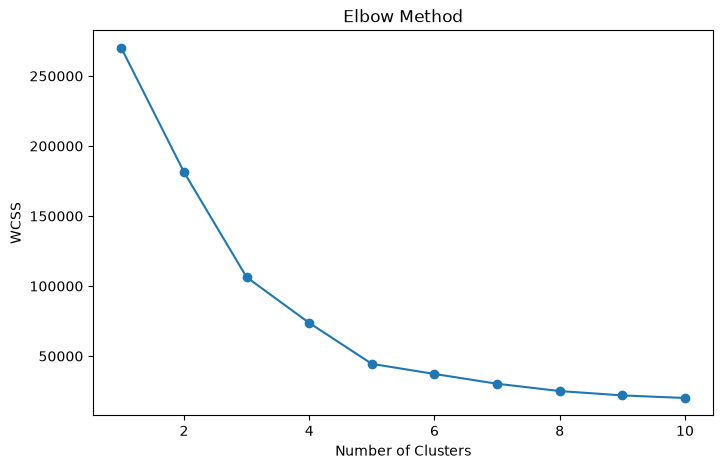

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [12]:
from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

print("Cluster Labels:")
print(y_kmeans)

Cluster Labels:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


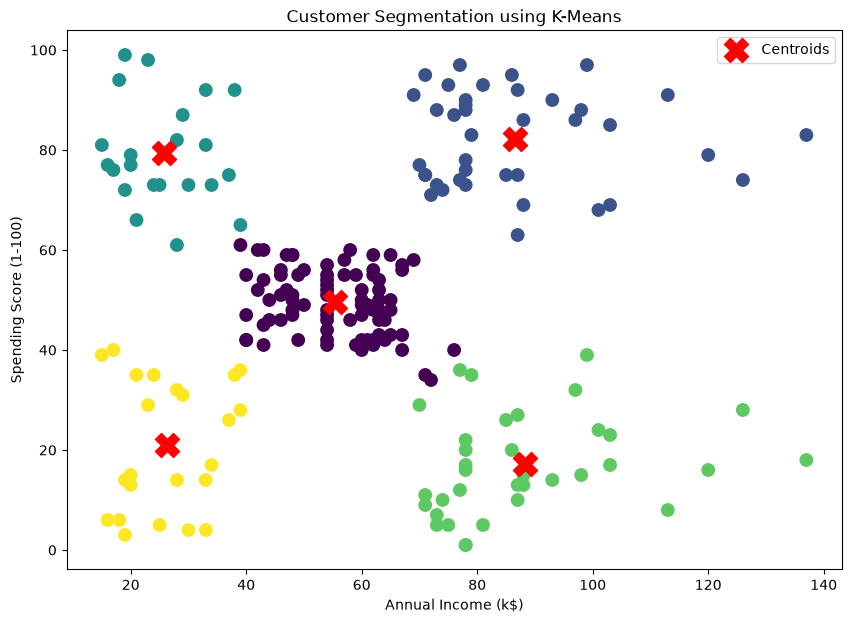

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [14]:
# Add cluster labels to the dataset
df["Cluster"] = y_kmeans

print("Customers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [15]:
cluster_summary = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)", "Age"]].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


# Conclusion

The Mall Customers dataset was successfully segmented using the K-Means Clustering algorithm.

The Elbow Method indicated that the optimal number of clusters was **5**.

The algorithm grouped customers based on their Annual Income and Spending Score into five distinct customer segments.

These customer segments can help businesses identify high-value customers, understand customer behavior, and design targeted marketing strategies.

This project demonstrates the practical use of Unsupervised Machine Learning for customer segmentation.